# <b>Programming for Data Science Project

meter numero do henrique
fazer boxplot com todas as colunas qu têm missing values instead uma por uma\
meter titulos como ta nas guidelines(carlota sabe)\
fazer um indice\
fazer boxplots para todos os missing values\
verfiicar o datatype de cada coluna e mudar oq tem a ser udado ANTES DO MULTIINDEX mas dps dos missing values

dúvidas: \
não deviamos tratar dos missing values só depois de tirar os duplicates ? assim quando usamos a mean ou a median esse valor está a ser influenciado por isso \
por ex na working age population tamos a basear nos nas outras cidades alemãs mas tipo será esse o melhor fator para nos basearmos? não nos deviamos basear por exemplo nas cidades que tenham uma população semelhante?\



cenas que queremos meter
uma varibale called cost of living
meter average rent


## <b>1. Introduction and Project Setup

### <b> 1.1. Our Group

**Group 19** 
- Carlota Marto 20241729 
- Henrique Santos 2024
- Laura Lisboa 20241783
- Tiago Carvalho 20241728

 ### <b> 1.2. Project Goal

&nbsp;&nbsp;&nbsp;&nbsp;The primary goal of this Notebook series is to perform a comprehensive, data-driven analysis to **empower users in making informed living decisions across European countries.** \
&nbsp;&nbsp;&nbsp;&nbsp;This project aims to simplify the complex choice of where to live by analyzing key national characteristics, such as **Cost of Living**, **Population Density** and **Employment**, and translating raw data into an **interpretable framework.** \
&nbsp;&nbsp;&nbsp;&nbsp;Ultimately, this project seeks to answer the central question: \
&nbsp;&nbsp;&nbsp;&nbsp;***Which European countries offer the optimal alignment with a user's personal values and life goals, based on quantitative metrics?***


 ### <b> 1.3. Import All the Necessary Libraries, the Dataset and Adjust the Name of Some Columns

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup       # process html
from selenium import webdriver      # automate web browser interaction
from selenium.webdriver.common.by import By #specify specify how to locate elements on a web page.
import requests 

In [43]:
dataset = pd.read_csv('city_data.csv', sep = '|', header = 1, index_col = 0)
dataset.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


**Add Information to the Name of the Columns and Correct Mistakes**

In [44]:
dataset.columns
#This line allows us to see the name of all the columns of the dataset

Index(['Population Density', 'Population', 'Working Age Population ',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Avgerage Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

&nbsp;&nbsp;&nbsp;&nbsp;We can observe that the column 'Working Age Population ' has a space in front, which can make it confusing to code with. Also, the column 'Avgerage Rent Price' has a spelling mistake which we are going to correct.\
&nbsp;&nbsp;&nbsp;&nbsp;We also decided that the dataset would become more clear if we added more information to some columns, for instance, the units in which the variable is measured or other informations we found useful.

In [45]:
dataset = dataset.rename(columns={'Population Density': 'Population Density (per km2)', 
                                  'Working Age Population ': 'Working Age Population (15-64 years)',
                                  'GDP per Capita': 'GDP per Capita ($)',
                                  'Days of very strong heat stress' : 'Days of very strong heat stress (>38ºC)',
                                  'Average Monthly Salary': 'Average Monthly Salary (€)', 
                                  'Avgerage Rent Price' : 'Average Rent Price (€)',
                                 })

In [46]:
dataset.head(1)

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita ($),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;The variable 'GDP per Capita' is measured in $ and, as there are other two columns where the values are measured in €, we are going to do the conversion of all the values in that column. We are sure that, that way, it is less confusing for someone trying to find the best place to live.\
&nbsp;&nbsp;&nbsp;&nbsp;In the third of November of 2025, the cost of 1 dolar was equal to 0.87 euros. 

In [47]:
dataset['GDP per Capita ($)'] = dataset['GDP per Capita ($)'] * 0.87  

In [48]:
dataset = dataset.rename(columns={'GDP per Capita ($)' : 'GDP per Capita (€)'})
dataset.head(1)

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


### **Adjust Some Data Types**

In [49]:
dataset.info()
#this line allows us to see the datatype of each column

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, Vienna, Austria to Adana, Turkiye
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Population Density (per km2)             85 non-null     float64
 1   Population                               86 non-null     int64  
 2   Working Age Population (15-64 years)     85 non-null     float64
 3   Youth Dependency Ratio                   86 non-null     float64
 4   Unemployment Rate                        85 non-null     float64
 5   GDP per Capita (€)                       85 non-null     float64
 6   Days of very strong heat stress (>38ºC)  86 non-null     int64  
 7   Main Spoken Languages                    85 non-null     object 
 8   Average Monthly Salary (€)               86 non-null     int64  
 9   Average Rent Price (€)                   86 non-null     int64  
 10  Average Cost of Living         

&nbsp;&nbsp;&nbsp;&nbsp;As we can see, there are some columns classified as 'float64' that do not make sense. For example, the Working Age Population and the GDP per Capita. We decided to change them to integers to make it easier to read. (Average Price Groceries also has that problem but we chose to ignore it for now because it is going to be removed.)

## **2. Data Wrangling and Exploratory Analysis**

&nbsp;&nbsp;&nbsp;&nbsp;In this part, we are going to handle the duplicate records and the missing values. We chose to handle the duplicate records firstly so that those records do not interfere with the imputation of the missing values

### **2.1. How to Handle Duplicate Records**

In [50]:
duplicate_records = dataset[dataset.duplicated(keep = False)]
duplicate_records
#these two lines shows us the duplicate records in the dataset

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;In the whole dataset we only have two duplicates: Berlin and Malaga. In the next line of code we are removing them.

In [51]:
dataset.drop_duplicates(inplace = True)

### **2.2. How to Handle Missing Values**

&nbsp;&nbsp;&nbsp;&nbsp;Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [52]:
dataset.isna().sum()

Population Density (per km2)                1
Population                                  0
Working Age Population (15-64 years)        1
Youth Dependency Ratio                      0
Unemployment Rate                           1
GDP per Capita (€)                          1
Days of very strong heat stress (>38ºC)     0
Main Spoken Languages                       1
Average Monthly Salary (€)                  0
Average Rent Price (€)                      0
Average Cost of Living                      0
Average Price Groceries                    78
Last Data Update                            0
dtype: int64


**Column 'Average Price Groceries'**

&nbsp;&nbsp;&nbsp;&nbsp;In the column 'Average Price Groceries' there are 80 missing values out of the 86 rows total. As there are only 6 records of average price groceries, this does not add up any valuable information, therefore, we decided to remove it.

In [53]:
dataset.drop('Average Price Groceries', axis = 1, inplace = True)
dataset.head(1) #this is just to visualise that the columns is not there anymore

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00


### 2.1.1. Missing Values in Categorical Variables

**Missing Value in 'Main Spoken Languages'**

&nbsp;&nbsp;&nbsp;&nbsp;For the missing value in 'Main Spoken Languages', we first need to understand in what row is the missing value located

In [54]:
dataset[dataset['Main Spoken Languages'].isna()]

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,NaN,3200,1100,2050,2024-01-15 00:00:00


&nbsp;&nbsp;&nbsp;&nbsp;As it is a **categorical** variable we have to deal with it with the mode. If we did not have the information about the country of the city, we would apply the mode to all the cities in the dataset, but, as we know that "Dusseldorf" is located in Germany we only apply the mode to all the **german cities** for a more accurate result.

In [55]:
dataset.loc[dataset.index.str.contains('Germany'), ['Main Spoken Languages']].mode()

,Main Spoken Languages
0,German


&nbsp;&nbsp;&nbsp;&nbsp;As we can observe, the most common main spoken language in german cities of the dataset is **'German'**. Therefore, we will replace the missing value with 'German'.

In [56]:
dataset.loc['Dusseldorf, Germany', 'Main Spoken Languages'] = 'German'
dataset.loc[['Dusseldorf, Germany']]

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


### 2.1.2. Missing Values in Numerical Variables

&nbsp;&nbsp;&nbsp;&nbsp;We can do many things with missing numerical values. There are cases where we must replace with the **median** and others where we must use the **mean**. This all depends if those columns have outliers or not, therefore, we decided that the best way to verify outliers is by creating a **boxplot for each variable**. As the columns with missing values have very different scales, we cannot put them all in the same graphic

\
**Missing Value in 'Working Age Population'**

&nbsp;&nbsp;&nbsp;&nbsp;For the missing value in the column 'Working Age Population', by the same logic we will replace it based on the other **german cities** as the only missing value is also located in Dusseldorf in Germany. This time, as it is a **numerical** variable instead of categorical we need to verify if there are outliers so, we create a boxplot that shows the distribution of working age population in german cities.

In [57]:
dataset[dataset['Working Age Population (15-64 years)'].isna()]
#Here we can confirm that the only missing value is actually in a german city

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


In [58]:
german_cities = dataset[dataset.index.str.contains('Germany')]
german_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29 00:00:00
"Hamburg, Germany",461.0,3315036,2181857.0,21.5,3.2,53120.46,0,"German, English, Turkish",3500,1100,2100,2024-07-10 00:00:00
"Munich, Germany",529.0,2907752,1955041.0,21.1,2.1,73049.55,1,"German, English",3540,1500,2550,2023-03-16 00:00:00
"Cologne, Germany",1233.0,2002550,1335299.0,20.8,3.9,52469.70,3,"German, English, Turkish",3200,1030,2000,2024-11-23 00:00:00
"Frankfurt am Main, Germany",631.0,2710501,1791435.0,22.0,3.2,60353.64,6,"German, English",3800,1300,2350,2023-02-04 00:00:00


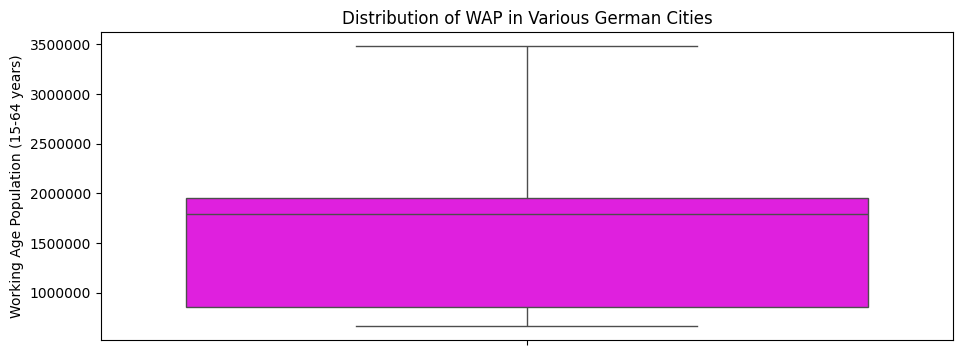

In [59]:
plt.figure(figsize = (11,4))
sns.boxplot(data = german_cities['Working Age Population (15-64 years)'], color = '#FF00FE')
plt.title('Distribution of WAP in Various German Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

&nbsp;&nbsp;&nbsp;&nbsp;As we can see above, there are no outliers in the Working Age Population in german cities. The mean is sensible to outliers, but as we do not have any we should use it to find the missing value.

In [60]:
print(f'The average Working Age Population in german cities is: {german_cities['Working Age Population (15-64 years)'].mean().round()}')

The average Working Age Population in german cities is: 1658169.0


In [61]:
dataset.loc['Dusseldorf, Germany', ['Working Age Population (15-64 years)']] =  german_cities['Working Age Population (15-64 years)'].mean().round()
dataset.loc[['Dusseldorf, Germany']]
#this two lines replace the missing value by the mean that was shown before and display the row with information about Dusseldorf, Germany

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,1658169.0,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


### Missing Value in 'Population Density'

In [62]:
dataset[dataset['Population Density (per km2)'].isna()]	
#this line allows us to see what city has the missing value in Population Density

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


By the same logic as the last one, we're going to compare Valencia to the other spainish cities and then, see the distribution of the Population Density in those cities. If it has outliers, we use the median, if not, we use the mean

In [63]:
spanish_cities = dataset[dataset.index.str.contains('Spain')]
spanish_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Madrid, Spain",873.0,6882461,4617753.0,23.0,10.8,44387.40,18,Spanish,2271,1100,1589,2023-05-14 00:00:00
"Barcelona, Spain",1918.0,5034925,3331345.0,22.6,11.0,39163.92,0,"Spanish, Catalan",2094,1450,1630,2024-10-18 00:00:00
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.90,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00
"Seville, Spain",330.0,1549641,1037225.0,25.0,21.6,26103.48,53,Spanish,2300,650,1150,2024-09-01 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,2023-11-27 00:00:00


Text(0.5, 1.0, 'Distribution of Population Density in Various Spanish Cities')

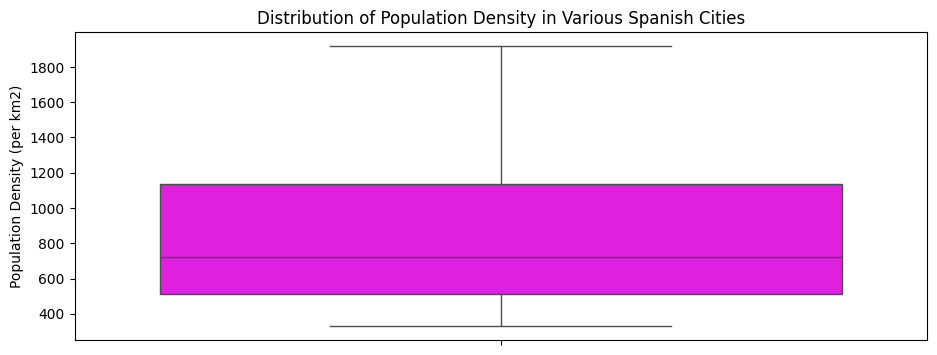

In [64]:
plt.figure(figsize = (11,4))
sns.boxplot(data = spanish_cities['Population Density (per km2)'], color = '#FF00FE')
plt.title('Distribution of Population Density in Various Spanish Cities')

In [65]:
print(f'The average Density Population in spanish cities is: {spanish_cities['Population Density (per km2)'].mean()}')

The average Density Population in spanish cities is: 923.0


In [66]:
dataset.loc['Valencia, Spain', ['Population Density (per km2)']] =  spanish_cities['Population Density (per km2)'].mean()
dataset.loc[['Valencia, Spain']]
#the boxplot does not have outliers, so we replace it by the mean

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",923.0,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


### Missing Value in 'Unemployment Rate'

We are going to repeat the process for all the left missing values. Firstly, see what city has the missing value in the Unemployment Rate column, then, create a new dataset with all the cities in that country and create a box plot with the distribution of the unemployment rate in those cities to verify the existence of outliers.

In [67]:
dataset[dataset['Unemployment Rate'].isna()]	
#we verify the missing value is in Gent in Belgium

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


In [68]:
belgium_cities = dataset[dataset.index.str.contains('Belgium')]
belgium_cities.head()

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Brussels, Belgium",681.0,3284548,2137425.0,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.80,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00
"Bruges, Belgium",840.0,119765,74600.0,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25 00:00:00


Text(0.5, 1.0, 'Distribution of Unemployment Rate in Various Belgium Cities')

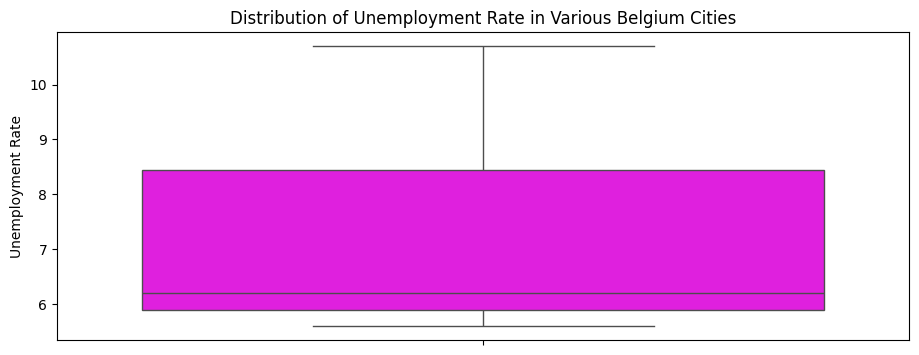

In [69]:
plt.figure(figsize = (11,4))
sns.boxplot(data = belgium_cities['Unemployment Rate'], color = '#FF00FE')
plt.title('Distribution of Unemployment Rate in Various Belgium Cities')

In [70]:
print(f'The average Unemployment Rate in belgium cities is: {belgium_cities['Unemployment Rate'].mean()}')

The average Unemployment Rate in belgium cities is: 7.5


In [71]:
dataset.loc['Gent, Belgium', ['Unemployment Rate']] =  belgium_cities['Unemployment Rate'].mean()
dataset.loc[['Gent, Belgium']]
#the boxplot does not have outliers, so we replace it by the mean

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


### Missing Value in 'GDP per Capita'

In [72]:
dataset[dataset['GDP per Capita (€)'].isna()]	
#we verify the missing value is in Lemesos in Cyprus

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


In [73]:
cyprus_cities = dataset[dataset.index.str.contains('Cyprus')]
cyprus_cities.head()

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Lefkosia, Cyprus",130.0,356400,237000.0,23.06,9.6,30369.09,45,"Greek, Turkish, English",1486,700,1350,2024-04-08 00:00:00
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


As there are only two cites in Cyprus, we can only impute a value in the missing value based on the other city, therefore we decided that we are going to use the same value for both.

In [74]:
dataset.loc['Lemesos;Cyprus', ['GDP per Capita (€)']] =  dataset.loc['Lefkosia, Cyprus', ['GDP per Capita (€)']]

### **2.3 Separating Cities and Countries**

While analyscbueid

In [75]:
dataset.rename(index ={'Greece, Athens': 'Athens, Greece'}, inplace = True)
dataset.loc[['Athens, Greece']]

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Athens, Greece",1829.0,3530371,2287174.0,22.0,17.2,33564.6,17,"Greek, English",1050,600,1200,2024-07-16 00:00:00


hh

In [76]:
dataset = dataset.reset_index().rename(columns={'index': 'City'})
dataset['City'] = dataset['City'].astype(str)
dataset[['City','Country']] = dataset['City'].str.split(r'[.,;]', expand = True)

In [77]:
dataset.set_index('City', inplace = True)
dataset.head()

,Population Density (per km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country
City,,,,,,,,,,,,,
Vienna,310.0,2983513,2018818.0,20.1,10.2,48519.90,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00,Austria
Salzburg,243.0,375489,250472.0,20.3,3.0,58019.43,0,German,3200,1100,2186,2023-11-03 00:00:00,Austria
Brussels,681.0,3284548,2137425.0,27.5,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00,Belgium
Antwerp,928.0,1139663,723396.0,27.7,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00,Belgium
Gent,552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00,Belgium


### **2.3. Guideline Questions**


#### **2.3.1.** Which country appears most frequently in the dataset? How many cities are associated with it?

#### **2.3.2.** How many cities are present in total? How many are associated with Greece?


#### **2.3.3.** Which is the least spoken language in the dataset? Which are the top 3 most spoken languages?

As there are cities in which there's more than one main spoken language, our solution was to create a list with all the languages spoken in all the cities (even if they are repeated) and then, create a counter that counts how many times each language appears on the list.

In [78]:
counter = dataset['Main Spoken Languages'].str.split(r'[,;]').explode().str.strip().value_counts()
#This line creates a counter that counts how many times each language appears on the list
#the split(r'[,;]') splits the string at each comma or semicolon
#the explode() transforms the elements to a list

top_3_languages = counter.head(3)
print(top_3_languages)
print('The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.')

least_spoken = counter.index[-1]
count_least_spoken = counter.iloc[-1]

print(f"The least spoken language is {least_spoken} with a count of {count_least_spoken}.")
#There are more than one language that only appear once in the dataset but Slovene is the one that appears in the last position in the list.

Main Spoken Languages
English    46
German     15
Turkish    10
Name: count, dtype: int64
The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.
The least spoken language is Slovene with a count of 1.


#### **2.3.4** Entries uploaded before April 2023 need to be updated. Which cities would require an update?

In [79]:
dataset['Last Data Update'].info()

<class 'pandas.core.series.Series'>
Index: 84 entries, Vienna to Adana
Series name: Last Data Update
Non-Null Count  Dtype 
--------------  ----- 
84 non-null     object
dtypes: object(1)
memory usage: 1.3+ KB


For us to be able to work with dates, we need to verify the data type of the column `Last Data Update` and, as we can see above, the data type is "object". The first to do then is to change the type.

In [80]:
dataset['Last Data Update'] = pd.to_datetime(dataset['Last Data Update']) #changes the datatype of the column to datetime
data_limit = pd.to_datetime('2023-04-01') #we define the date limit

cities_need_update = dataset[dataset['Last Data Update'] < data_limit] #this lines creates a new dataset with all the cities updated before April 1st, 2023
print(f'The cities that need an update are {', '.join(cities_need_update.index.tolist())}') 
#this turns the index of the df into a list, and joins the elements with a comma and space between them, so that it looks better when printed

The cities that need an update are Basel, Munich, Frankfurt am Main, Lyon, Venice, Gothenburg


#### **2.3.5** How many days ago was the last update? On what day, month, and year did it occur?

In [81]:
last_update = dataset['Last Data Update'].max() #this tells us the most recent date in the column, which means the last update
day = last_update.day
month = last_update.month
year = last_update.year
print(f'The most recent update was on {day}/{month}/{year}.')

The most recent update was on 12/12/2024.


In [82]:
#this was written on November 20th, 2025
todays_date = pd.to_datetime('2025-11-20')
days_since_update = (todays_date - last_update).days
print(f'The last update was {days_since_update} days ago.')

The last update was 343 days ago.


#### **2.3.6** How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? Provide a **visual representation**.


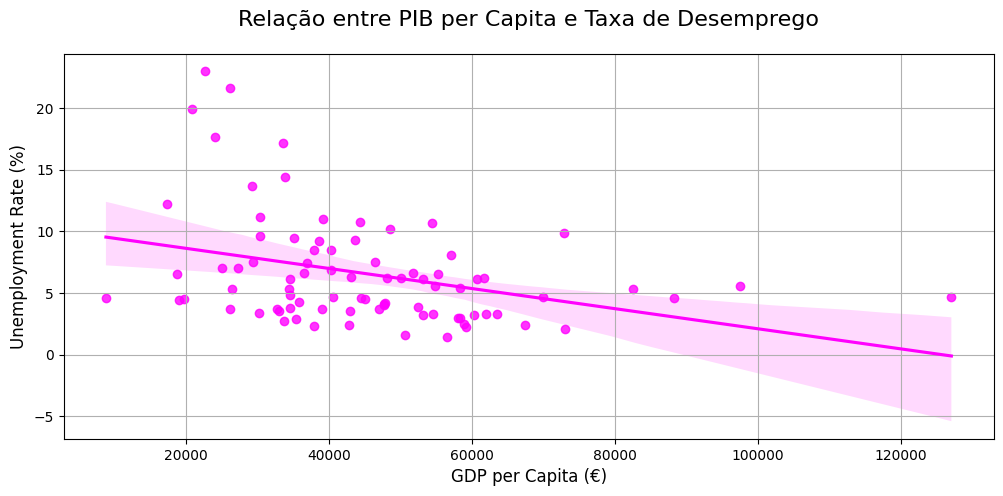

In [83]:
plt.figure(figsize=(12, 5))
#regplot includes the regression line
sns.regplot(x=dataset['GDP per Capita (€)'], y=dataset['Unemployment Rate'], color = '#FF00FE')
plt.grid(True)
plt.title('Relação entre PIB per Capita e Taxa de Desemprego', fontsize=16, pad=20)
plt.xlabel('GDP per Capita (€)', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

plt.show()

##### **Regression Line**

There is a negative correlation between `GDP per Capita (€)` and the `Unemployment Rate` . As the GDP increases, the unemployment rate tends to decrease.

##### **Central Tendency**

The majority of the cities in our dataset have a GDP per Capita between **30,000€ and 60,000€** and Unemployment Rate between **4% and 10%**

There are cities

#### **2.3.7** Which are the top 5 cities with the largest difference between the Average Monthly Salary and Average Cost of Living? What about the top 5 countries with the smallest average difference? Show these results with meaningful visualizations.

#### **2.3.8** Which is the best city for someone seeking:
- an average monthly salary above €1600,
- a cost of living below €900, and
- a country suitable for starting a family (with a relatively larger youth population)?

#### **2.3.9** What are three additional insights you find meaningful when comparing the given cities?

fazer maybe no final

## Building an Interactive Map

### Web Scraping


In [ ]:
import time
from selenium.webdriver.chrome.options import Options #interact with page


options = Options()
browser = webdriver.Chrome(options=options)
browser.get("https://en.wikipedia.org/wiki/Main_Page")
time.sleep(3)  # wait for 3 seconds to let the page load

search_button = browser.find_elements(By.CLASS_NAME, 'vector-icon mw-ui-icon-search mw-ui-icon-wikimedia-search')
search_button[0].click()

search_bar = browser.find_elements(By.CLASS_NAME, 'cdx-text-input__input')


#preciso de criar um for loop para obter as coordenadas de todas as cities, num loop
for city in dataset.index:
    search_bar[0].clear()
    search_bar[0].send_keys(city)
    time.sleep(2)  # wait for 2 seconds to let the suggestions load
    first_result = browser.find_elements(By.CLASS_NAME, 'cdx-search-suggestions__item')
    if first_result:
        first_result[0].click()
        time.sleep(2)  # wait for 2 seconds to let the page load
        soup = BeautifulSoup(browser.page_source, 'html.parser')
        coord = soup.find('span', class_='geo-dec')
        if coord:
            print(f"{city}: {coord.text}")
        else:
            print(f"{city}: Coordinates not found")
    else:
        print(f"{city}: No search results found")




Vienna: search failed (Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=142.0.7444.176); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x7ff66c40a235
	0x7ff66c162630
	0x7ff66bef16dd
	0x7ff66bedd205
	0x7ff66bf02a8a
	0x7ff66bf7a476
	0x7ff66bf9b3d2
	0x7ff66bf3b0ed
	0x7ff66bf3bf63
	0x7ff66c435d60
	0x7ff66c42fe8a
	0x7ff66c451005
	0x7ff66c17d71e
	0x7ff66c184e1f
	0x7ff66c16b7c4
	0x7ff66c16b97f
	0x7ff66c1518e8
	0x7ff97adfe8d7
	0x7ff97cdec53c
)


InvalidSessionIdException: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x7ff66c40a235
	0x7ff66c162630
	0x7ff66bef14e5
	0x7ff66bf3a151
	0x7ff66bf72a12
	0x7ff66bf6d27c
	0x7ff66bf6c46a
	0x7ff66bebacb5
	0x7ff66c435d60
	0x7ff66c42fe8a
	0x7ff66c451005
	0x7ff66c17d71e
	0x7ff66c184e1f
	0x7ff66beb977b
	0x7ff66c5845f8
	0x7ff97adfe8d7
	0x7ff97cdec53c


# 